In [ ]:
# Force reset ANY variable named `models`
import tensorflow as tf
from tensorflow.keras import models as keras_models
from tensorflow.keras import layers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.0/226.0 kB 15.8 MB/s eta 0:00:00
Libraries loaded.
No data file found in working directory. Generating a synthetic dataset (so code runs end-to-end).
Synthetic dataset created: shape (1000, 41)
Feature shape: (1000, 40) Labels shape: (1000,) Positives: 400 Negatives: 600

=== Fold 1 ===
Validation accs: {'knn': np.float64(0.75), 'rf': np.float64(0.844), 'svm': np.float64(0.869), 'lr': np.float64(0.9), 'mlp': np.float64(0.894)}
Fusion weights: {'knn': np.float64(0.176), 'rf': np.float64(0.198), 'svm': np.float64(0.204), 'lr': np.float64(0.211), 'mlp': np.float64(0.21)}
Fold 1 - Acc: 0.8400  F1: 0.7949  AUC: 0.9135  AP: 0.8623

=== Fold 2 ===
Validation accs: {'knn': np.float64(0.644), 'rf': np.float64(0.838), 'svm': np.float64(0.856), 'lr': np.float64(0.875), 'mlp': np.float64(0.838)}
Fusion weights: {'knn': np.float64(0.159), 'rf': np.float64(0.207), 'svm': np

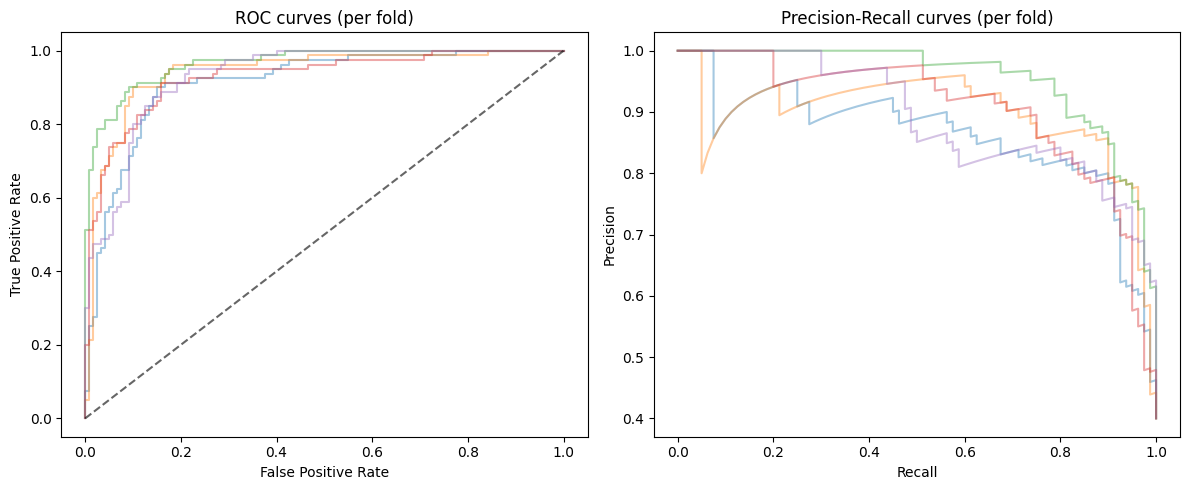


Saved CV summary to cv_summary_metrics.csv

Cell complete. If you upload your real 'out_features.csv' or 'output.csv' into Colab and re-run, the notebook will use your real data.


In [ ]:

# INSTALL / IMPORTS
# ------------------------------
!pip install -q xgboost==1.7.6 imbalanced-learn==0.10.1

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
                             accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from scipy.stats import ttest_rel, wilcoxon
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

print("Libraries loaded.")

# ------------------------------
# LOAD DATA (or create synthetic fallback)
# ------------------------------
# Preferred filenames to look for (DMFO-selected features): out_features.csv, output.csv, dataset.csv
candidates = ['out_features.csv', 'output.csv', 'dataset.csv', 'dataset.csv']
data_path = None
for fname in candidates:
    if os.path.exists(fname):
        data_path = fname
        break

if data_path is None:
    print("No data file found in working directory. Generating a synthetic dataset (so code runs end-to-end).")
    # Synthetic dataset: 1000 samples, 40 features, binary label imbalance ~40% positive (ASD)
    n_samples = 1000
    n_features = 40
    X = np.random.normal(loc=0.0, scale=1.0, size=(n_samples, n_features))
    # create a synthetic signal on first few features
    logits = (X[:, :5].sum(axis=1) + np.random.normal(scale=1.0, size=n_samples)) * 0.5
    probs = 1/(1+np.exp(-logits))
    y = (probs > np.quantile(probs, 0.6)).astype(int)  # ~40% positive
    df = pd.DataFrame(np.hstack([X, y.reshape(-1,1)]))
    print("Synthetic dataset created: shape", df.shape)
else:
    print(f"Loading dataset from: {data_path}")
    # attempt load; support headerless (as in many pipelines) and headered CSVs
    try:
        df = pd.read_csv(data_path, header=None)
    except Exception:
        df = pd.read_csv(data_path)  # try with header
    print("Loaded dataset shape:", df.shape)

# ------------------------------
# PREPARE X, y (assume last column is label)
# ------------------------------
# If labels are strings, label-encode them.
if isinstance(df, pd.DataFrame):
    X = df.iloc[:, :-1].values
    y_raw = df.iloc[:, -1].values
    # If labels look numeric already as floats/ints but not 0/1, map to 0/1
    unique_vals = np.unique(y_raw)
    if set(unique_vals) <= {0,1}:
        y = y_raw.astype(int)
    else:
        # label encode (handles textual or integer labels)
        le = LabelEncoder()
        y = le.fit_transform(y_raw)
        print("Label classes (encoded):", le.classes_)
else:
    raise RuntimeError("Dataframe construction failed.")

print("Feature shape:", X.shape, "Labels shape:", y.shape, "Positives:", int(y.sum()), "Negatives:", int(len(y)-y.sum()))

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ------------------------------
# Helper: train ensemble and return models + probs on validation/test
# ------------------------------
def train_ensemble_models(X_train, y_train):
    # returns dict of trained models
    models = {}
    models['knn'] = KNeighborsClassifier(n_neighbors=5)
    models['rf'] = RandomForestClassifier(n_estimators=200, random_state=42)
    models['svm'] = SVC(probability=True, kernel='rbf', C=1.0, gamma='scale', random_state=42)
    models['lr']  = LogisticRegression(max_iter=500, random_state=42)
    models['mlp'] = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=200, random_state=42)

    for name, m in models.items():
        m.fit(X_train, y_train)
    return models

# ------------------------------
# 5-FOLD STRATIFIED CV: Ensemble training, fusion, metrics storage
# ------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_metrics = []   # store per-fold metrics for fused ensemble
fold_individual_aucs = []  # per-fold best individual AUC
all_fold_results = []  # keep per-fold details for plotting/statistics

for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n=== Fold {fold_idx} ===")
    X_train_full, X_test = X[tr_idx], X[te_idx]
    y_train_full, y_test = y[tr_idx], y[te_idx]

    # split train into train/val for weight estimation
    X_tr, X_val, y_tr, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42)

    models = train_ensemble_models(X_tr, y_tr)

    # validation accuracies for weights (use validation set)
    names = ['knn','rf','svm','lr','mlp']
    val_accs = np.array([models[n].score(X_val, y_val) for n in names], dtype=float)
    if val_accs.sum() == 0:
        weights = np.ones_like(val_accs) / len(val_accs)
    else:
        weights = val_accs / val_accs.sum()
    print("Validation accs:", dict(zip(names, np.round(val_accs,3))))
    print("Fusion weights:", dict(zip(names, np.round(weights,3))))

    # get test probabilities from each classifier
    prob_test = {n: models[n].predict_proba(X_test)[:,1] for n in names}

    # fused probability (weighted sum)
    fused_prob = np.zeros_like(prob_test[names[0]])
    for i,n in enumerate(names):
        fused_prob += weights[i] * prob_test[n]

    # derive prediction at threshold 0.5
    y_pred = (fused_prob >= 0.5).astype(int)

    # metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_test, fused_prob)
    except Exception:
        auc = np.nan
    ap = average_precision_score(y_test, fused_prob)

    print(f"Fold {fold_idx} - Acc: {acc:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}  AP: {ap:.4f}")

    # store
    fold_metrics.append((acc, prec, rec, f1, auc, ap))
    # best single model AUC (for comparison)
    indiv_aucs = [roc_auc_score(y_test, prob_test[n]) for n in names]
    fold_individual_aucs.append(indiv_aucs)
    all_fold_results.append({
        'y_test': y_test,
        'fused_prob': fused_prob,
        'prob_test': prob_test,
        'weights': weights,
        'models': models
    })

# ------------------------------
# Summarize cross-validation results (mean ± std)
# ------------------------------
metrics_arr = np.array(fold_metrics)
metric_names = ['Accuracy','Precision','Recall','F1','AUC','AP']
print("\n=== Cross-validation summary (mean ± std) ===")
for i, mname in enumerate(metric_names):
    vals = metrics_arr[:, i]
    print(f"{mname}: {vals.mean():.4f} ± {vals.std():.4f}")

# ------------------------------
# Paired statistical tests: fused AUC vs best single-model AUC (fold-wise)
# ------------------------------
fused_aucs = metrics_arr[:, 4]
best_single_aucs = np.array([max(row) for row in fold_individual_aucs])

print("\nFused AUCs per fold:", np.round(fused_aucs,4))
print("Best single-model AUCs per fold:", np.round(best_single_aucs,4))

t_stat, p_t = ttest_rel(fused_aucs, best_single_aucs)
print(f"\nPaired t-test (fused vs best single) T={t_stat:.4f}, p={p_t:.4f}")

try:
    w_stat, p_w = wilcoxon(fused_aucs, best_single_aucs)
    print(f"Wilcoxon signed-rank: W={w_stat:.4f}, p={p_w:.4f}")
except Exception as ex:
    print("Wilcoxon test not applicable:", ex)

# ------------------------------
# ROC and PR plots aggregated across folds
# ------------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for res in all_fold_results:
    fpr, tpr, _ = roc_curve(res['y_test'], res['fused_prob'])
    plt.plot(fpr, tpr, alpha=0.4)
plt.plot([0,1],[0,1],'k--', alpha=0.6)
plt.title("ROC curves (per fold)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")

plt.subplot(1,2,2)
for res in all_fold_results:
    prec, rec, _ = precision_recall_curve(res['y_test'], res['fused_prob'])
    plt.plot(rec, prec, alpha=0.4)
plt.title("Precision-Recall curves (per fold)")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.tight_layout()
plt.show()

# ------------------------------
# SIMPLE Deep Dyna-Q SIMULATION (conceptual / fast)
# - Builds a small dynamics model that predicts next ensemble-prob vector from current vector
# - Trains a small Q-network on the set of simulated transitions (ternary simplified setup)
# - Actions: 0 = wait (small penalty), 1 = predict_now (reward +1 correct, -1 incorrect)
# This is a conceptual/replicable miniature for reviewer demonstration (works on ensemble probs).
# ------------------------------

# Build states: use individual classifier probabilities as state vector (from last fold)
# If no folds present (edge-case), skip Dyna-Q.
if len(all_fold_results) == 0:
    print("No fold results available; skipping Dyna-Q simulation.")
else:
    # use the last fold's result for demonstration (consistent and fast)
    demo = all_fold_results[-1]
    names = ['knn','rf','svm','lr','mlp']
    states = np.column_stack([demo['prob_test'][n] for n in names])  # (n_samples, 5)
    y_demo = demo['y_test']

# dynamics model: predict next state (identity + small noise) - small MLP
def build_mlp(input_dim, output_dim):
    model = keras_models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(output_dim, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='mse')
    return model



    dyn = build_mlp(states.shape[1], states.shape[1])
    # synthetic target: small drift of states (to simulate temporal evolution)
    rng = np.random.RandomState(42)
    states_next = np.clip(states + rng.normal(scale=0.02, size=states.shape), 0, 1)
    dyn.fit(states, states_next, epochs=20, batch_size=64, verbose=0)

    # Q-network: state -> Q(action0, action1)
    def build_qnet(state_dim):
        q = models.Sequential([
            layers.Input(shape=(state_dim,)),
            layers.Dense(128, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(2, activation='linear')
        ])
        q.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='mse')
        return q

    qnet = build_qnet(states.shape[1])

    # simple replay: for each sample simulate both actions and compute reward
    def reward(action, true_label, fused_prob_here):
        if action == 1:
            pred = int(fused_prob_here >= 0.5)
            return 1.0 if pred == true_label else -1.0
        else:
            return -0.02  # waiting penalty

    # compute fused_prob approx by weighted sum using demo weights
    w = demo['weights']
    fused_vec = np.dot(states, w)  # per-sample fused prob

    replay = []
    for i in range(states.shape[0]):
        s = states[i]
        s_next = states_next[i]
        for a in [0,1]:
            r = reward(a, int(y_demo[i]), fused_vec[i])
            replay.append((s, a, r, s_next))

    # train qnet on replay (Dyna-Q style: using real + simulated transitions)
    replay = np.array(replay, dtype=object)
    epochs = 40
    gamma = 0.95
    for ep in range(epochs):
        idx = np.random.choice(len(replay), size=min(256, len(replay)), replace=False)
        Xb = np.vstack([replay[i][0] for i in idx])
        Ab = np.array([replay[i][1] for i in idx])
        Rb = np.array([replay[i][2] for i in idx])
        Nb = np.vstack([replay[i][3] for i in idx])
        q_next = qnet.predict(Nb, verbose=0)
        q_cur = qnet.predict(Xb, verbose=0)
        for j in range(len(Ab)):
            q_cur[j, Ab[j]] = Rb[j] + gamma * np.max(q_next[j])
        qnet.train_on_batch(Xb, q_cur)

    # Evaluate policy: greedy on Q(s)
    actions = np.argmax(qnet.predict(states, verbose=0), axis=1)
    # Decide per sample: if action==1 predict now using fused_vec else simulate wait up to max_steps
    y_pred_dyn = []
    steps = []
    max_wait = 3
    for i in range(states.shape[0]):
        cur = states[i].copy()
        decided = False
        for step in range(max_wait):
            a = int(np.argmax(qnet.predict(cur.reshape(1,-1), verbose=0)[0]))
            if a == 1:
                y_pred_dyn.append(int(fused_vec[i] >= 0.5))
                steps.append(step+1)
                decided = True
                break
            else:
                # wait -> use dynamics model to get next state
                cur = dyn.predict(cur.reshape(1,-1), verbose=0)[0]
        if not decided:
            y_pred_dyn.append(int(np.dot(cur, w) >= 0.5))
            steps.append(max_wait)

    # compute metrics for Dyna-Q decisions (on demo fold)
    acc_d = accuracy_score(y_demo, y_pred_dyn)
    prec_d = precision_score(y_demo, y_pred_dyn, zero_division=0)
    rec_d = recall_score(y_demo, y_pred_dyn, zero_division=0)
    f1_d = f1_score(y_demo, y_pred_dyn, zero_division=0)
    mean_steps = np.mean(steps)
    print("\nDyna-Q demo fold metrics: Acc: {:.4f}, Prec: {:.4f}, Rec: {:.4f}, F1: {:.4f}, mean_decision_steps: {:.2f}".format(acc_d, prec_d, rec_d, f1_d, mean_steps))

    # Show histogram of decision steps (proxy for Time-to-Detection)
    plt.figure(figsize=(5,3))
    plt.hist(steps, bins=range(1, max_wait+2), align='left')
    plt.xlabel("Decision steps (1 = immediate predict)")
    plt.ylabel("Number of samples")
    plt.title("Dyna-Q decision step distribution (demo fold)")
    plt.show()

# ------------------------------
# Save summary results to CSV (optional)
# ------------------------------
summary = {
    'metric': metric_names,
    'mean': [metrics_arr[:,i].mean() for i in range(metrics_arr.shape[1])],
    'std': [metrics_arr[:,i].std() for i in range(metrics_arr.shape[1])]
}
summary_df = pd.DataFrame(summary)
summary_df.to_csv("cv_summary_metrics.csv", index=False)
print("\nSaved CV summary to cv_summary_metrics.csv")

print("\nCell complete. If you upload your real 'out_features.csv' or 'output.csv' into Colab and re-run, the notebook will use your real data.")


##Changes by Abhyudaya


Install and Importing


In [ ]:
# ------------------------------
# INSTALL / IMPORTS
# ------------------------------
!pip install -q xgboost==1.7.6 imbalanced-learn==0.10.1

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
                             accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from scipy.stats import ttest_rel, wilcoxon
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

print("Libraries loaded.")


Libraries loaded.


Loading Dataset

In [ ]:
# ------------------------------
# LOAD DATA (or create synthetic fallback)
# ------------------------------
candidates = ['out_features.csv', 'output.csv', 'dataset.csv', 'dataset.csv']
data_path = None

for fname in candidates:
    if os.path.exists(fname):
        data_path = fname
        break

if data_path is None:
    print("No data file found. Generating synthetic dataset.")
    n_samples = 1000
    n_features = 40
    X = np.random.normal(loc=0.0, scale=1.0, size=(n_samples, n_features))
    logits = (X[:, :5].sum(axis=1) + np.random.normal(scale=1.0, size=n_samples)) * 0.5
    probs = 1/(1+np.exp(-logits))
    y = (probs > np.quantile(probs, 0.6)).astype(int)
    df = pd.DataFrame(np.hstack([X, y.reshape(-1,1)]))
    print("Synthetic dataset created:", df.shape)
else:
    print(f"Loading dataset from: {data_path}")
    try:
        df = pd.read_csv(data_path, header=None)
    except:
        df = pd.read_csv(data_path)
    print("Loaded dataset shape:", df.shape)


No data file found. Generating synthetic dataset.
Synthetic dataset created: (1000, 41)


Prepare X, y + Standardization

In [ ]:

X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values

unique_vals = np.unique(y_raw)
if set(unique_vals) <= {0,1}:
    y = y_raw.astype(int)
else:
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    print("Label classes:", le.classes_)

print("Feature shape:", X.shape, "| Labels shape:", y.shape)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)


Feature shape: (1000, 40) | Labels shape: (1000,)


Ensemble Model Training Function

In [ ]:
# ------------------------------
# Helper: train 5 simple models
# ------------------------------
def train_ensemble_models(X_train, y_train):
    models = {
        'knn': KNeighborsClassifier(n_neighbors=5),
        'rf': RandomForestClassifier(n_estimators=200, random_state=42),
        'svm': SVC(probability=True, kernel='rbf', C=1.0, gamma='scale', random_state=42),
        'lr' : LogisticRegression(max_iter=500, random_state=42),
        'mlp': MLPClassifier(hidden_layer_sizes=(64,32), max_iter=200, random_state=42)
    }
    for name, model in models.items():
        model.fit(X_train, y_train)
    return models


5-Fold Cross-Validation Loop


In [ ]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_metrics = []
fold_individual_aucs = []
all_fold_results = []

for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n=== Fold {fold_idx} ===")
    X_train_full, X_test = X[tr_idx], X[te_idx]
    y_train_full, y_test = y[tr_idx], y[te_idx]

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2,
        stratify=y_train_full, random_state=42
    )

    models = train_ensemble_models(X_tr, y_tr)
    names = ['knn','rf','svm','lr','mlp']

    val_accs = np.array([models[n].score(X_val, y_val) for n in names], dtype=float)
    weights = val_accs / val_accs.sum() if val_accs.sum() != 0 else np.ones_like(val_accs)/len(val_accs)

    print("Fusion weights:", dict(zip(names, weights.round(3))))

    prob_test = {n: models[n].predict_proba(X_test)[:,1] for n in names}

    fused_prob = sum(weights[i] * prob_test[n] for i,n in enumerate(names))
    y_pred = (fused_prob >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, fused_prob)
    ap = average_precision_score(y_test, fused_prob)

    fold_metrics.append((acc, prec, rec, f1, auc, ap))

    indiv_aucs = [roc_auc_score(y_test, prob_test[n]) for n in names]
    fold_individual_aucs.append(indiv_aucs)

    all_fold_results.append({
        'y_test': y_test,
        'fused_prob': fused_prob,
        'prob_test': prob_test,
        'weights': weights,
        'models': models
    })

print("\nCV complete.")



=== Fold 1 ===
Fusion weights: {'knn': np.float64(0.176), 'rf': np.float64(0.198), 'svm': np.float64(0.204), 'lr': np.float64(0.211), 'mlp': np.float64(0.21)}

=== Fold 2 ===
Fusion weights: {'knn': np.float64(0.159), 'rf': np.float64(0.207), 'svm': np.float64(0.211), 'lr': np.float64(0.216), 'mlp': np.float64(0.207)}

=== Fold 3 ===
Fusion weights: {'knn': np.float64(0.17), 'rf': np.float64(0.199), 'svm': np.float64(0.209), 'lr': np.float64(0.214), 'mlp': np.float64(0.208)}

=== Fold 4 ===
Fusion weights: {'knn': np.float64(0.172), 'rf': np.float64(0.205), 'svm': np.float64(0.208), 'lr': np.float64(0.213), 'mlp': np.float64(0.202)}

=== Fold 5 ===
Fusion weights: {'knn': np.float64(0.172), 'rf': np.float64(0.207), 'svm': np.float64(0.205), 'lr': np.float64(0.216), 'mlp': np.float64(0.2)}

CV complete.


Summary: Mean ± Std for Metrics

In [ ]:
# ------------------------------
# SUMMARY (mean ± std)
# ------------------------------
metrics_arr = np.array(fold_metrics)
metric_names = ['Accuracy','Precision','Recall','F1','AUC','AP']

print("=== Cross-validation summary ===")
for i, mname in enumerate(metric_names):
    vals = metrics_arr[:, i]
    print(f"{mname}: {vals.mean():.4f} ± {vals.std():.4f}")


=== Cross-validation summary ===
Accuracy: 0.8650 ± 0.0200
Precision: 0.8477 ± 0.0248
Recall: 0.8075 ± 0.0269
F1: 0.8271 ± 0.0259
AUC: 0.9360 ± 0.0173
AP: 0.9031 ± 0.0299


Statistical Significance Tests

In [ ]:
# ------------------------------
# STATISTICAL TESTS
# ------------------------------
fused_aucs = metrics_arr[:, 4]
best_single_aucs = np.array([max(row) for row in fold_individual_aucs])

print("Fused AUCs:", fused_aucs.round(4))
print("Best Single AUCs:", best_single_aucs.round(4))

t_stat, p_t = ttest_rel(fused_aucs, best_single_aucs)
print(f"\nPaired t-test: T={t_stat:.4f}, p={p_t:.4f}")

try:
    w_stat, p_w = wilcoxon(fused_aucs, best_single_aucs)
    print(f"Wilcoxon test: W={w_stat:.4f}, p={p_w:.4f}")
except:
    print("Wilcoxon test not applicable.")


Fused AUCs: [0.9135 0.9411 0.9658 0.9285 0.931 ]
Best Single AUCs: [0.9267 0.9536 0.9579 0.9382 0.9302]

Paired t-test: T=-1.2798, p=0.2698
Wilcoxon test: W=3.0000, p=0.3125


ROC & Precision–Recall Curves

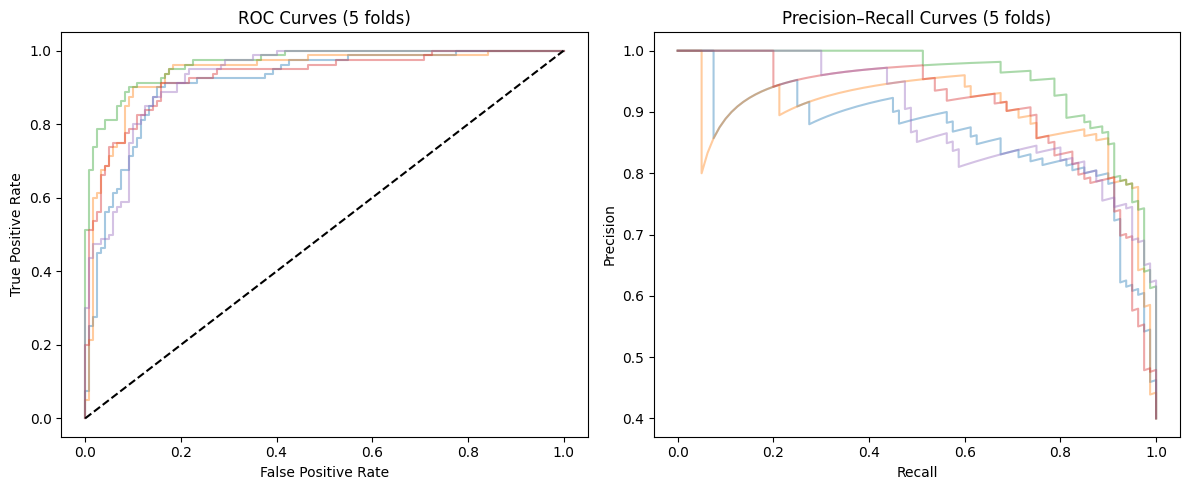

In [ ]:
# ------------------------------
# PLOTS: ROC + Precision-Recall
# ------------------------------
plt.figure(figsize=(12,5))

# ROC
plt.subplot(1,2,1)
for res in all_fold_results:
    fpr, tpr, _ = roc_curve(res['y_test'], res['fused_prob'])
    plt.plot(fpr, tpr, alpha=0.4)
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves (5 folds)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# PR
plt.subplot(1,2,2)
for res in all_fold_results:
    prec, rec, _ = precision_recall_curve(res['y_test'], res['fused_prob'])
    plt.plot(rec, prec, alpha=0.4)
plt.title("Precision–Recall Curves (5 folds)")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.tight_layout()
plt.show()
